# Uncomputation Using Qubricks

In this tutorial, we will discuss one of the core features of Qubricks: uncomputation.

## Uncomputation in quantum algorithms

Quantum programs spend approximately half of their operations performing reversible quantum logic and the other half - reversing that logic. Reversing parts of earlier computation is called _uncomputation_, and it is an extremely important building block of quantum algorithms.

Here are several common scenarios that require uncomputation.

### Undoing changes to the input qubits state 

Your computation modified the state of the input qubits (for example, to calculate an intermediate result in-place and use it as a condition for another step) and now needs their original state for the next calculation step. You need to undo the part of the computation which modified the state of the input qubits.

For example, consider a marking oracle that checks whether a bit string $x$ of length $2n$ satisfies several conditions, and the first of these conditions is "bit string $x$ is symmetric" (that is, the first half of the bit string equals the reverse of the second half). You can evaluate this condition as follows:

1. For each pair of bits $x_j$ and $x_{2n-1-j}$, compute their XOR in-place using a CNOT gate, with qubit $j$ as the target and qubit $2n-1-j$ as the control.
2. Check that all XORs equal $0$ using a multi-controlled $X$ gate with the first $n$ qubits as controls and an auxiliary qubit as target.
3. At this point, you have evaluated the first condition, but you need to evaluate other conditions as well, and they are defined in terms of the original values of $x$ rather than a mix of the original values and XORs that the input register holds now. This means that you need to uncompute step 1 and return the input register to its original state.


### Unentangling auxiliary qubits from the "main" qubits

Your computation required auxiliary qubits to store intermediate results. These qubits ended up entangled with the "main" qubits, which can lead to incorrect program behavior down the line. To unentangle them, you need to undo the parts of the computation which target these auxiliary qubits.

Let's return to our example of the marking oracle that checks whether the bit string $x$ satisfies several conditions. Each of the conditions will be evaluated separately, and the results will be stored in auxiliary qubits. After that, the final result will be computed as an AND of these auxiliary qubits and stored in the output qubit. This will leave all three registers - the input, the auxiliary qubits, and the output - entangled with each other. However, the quantum algorithms that rely on this oracle assume that only the input and the output are entangled and are constructed based on this assumption. Leaving the auxiliary qubits entangled with the other two registers will cause the program to behave in unexpected ways, introducing hard-to-debug issues.

> Here is the simplest example in which having an additional qubit entangled with the data qubit leads to unexpected behavior.
>
> Let's say we have a qubit that is either in the $\tfrac1{\sqrt2}(|0\rangle + |1\rangle)$ state or in the $\tfrac1{\sqrt2}(|0\rangle - |1\rangle)$ state, and we want to figure out which state it is. We can apply an $H$ gate to convert the first state to $|0\rangle$ and the second state to $|1\rangle$ and then measure the resulting state.
> 
> Now, let's imagine we have another qubit unwittingly entangled with this one. The two-qubit system is either in the $\tfrac1{\sqrt2}(|00\rangle + |11\rangle)$ state or in the $\tfrac1{\sqrt2}(|00\rangle - |11\rangle)$ state, but we're only looking at the first qubit, and we're not aware of the entanglement between it and the second one. Now our solution of applying an $H$ gate and measuring will not work! Instead, it will produce a probabilistic result, $0$ or $1$ with $50\%$ chance each, for both initial states. Having the second qubit entangled with the first one prevented the interference from happening the way we expected.


## Types of uncomputation in Workbench

Workbench aims to handle most uncomputation scenarios automatically, so that the developer doesn't have to implement each operation twice - once for the forward direction and once for the reverse. However, some scenarios cannot be handled automatically, and others are much more efficient to manage manually. Workbench offers a variety of ways to handle uncomputation for different requirements:

* _Automatic uncomputation_ undoes the computation by applying the instructions issued during the computation in reverse order.
* _Daggered computation_ applies an adjoint of the computation without the assumption that the computation has already happened. This is useful when "uncomputation" has to be performed before the computation.
* _Custom uncomputation_ allows the developer to specify the instructions to be used for uncomputation. This is useful when it is possible to do uncomputation more efficiently compared to reversing the computation instructions.
* _Disabling uncomputation_ allows the developer to specify that the computation cannot or shouldn't be uncomputed.

Let's take a closer look at each of these scenarios.


## Automatic uncomputation

Automatic uncomputation is the most straightforward way to handle uncomputation. 

* Workbench keeps track of instructions issued by a Qubrick when its `compute` method is called.
* To uncompute, you call the `uncompute` method of this Qubrick. This call applies the instructions issued by the `compute` method in reverse order, taking adjoint (inverse) of each instruction. 

The following code snippet shows an example of applying QFT to a qubit register and then uncomputing it. QFT is just a simple sequence of gates, and you can see that in the `uncompute` block this sequence of gates is reversed, and each gate is replaced by its adjoint: $S$ and $T$ gates become $S^\dagger$ and $T^\dagger$, and the rotation angles of rotation gates are multiplied by $-1$.

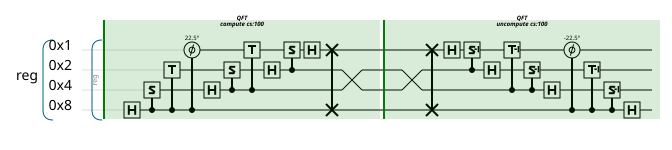

In [1]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.qft import QFT

qpu = QPU(num_qubits=4)
reg = Qubits(4, "reg", qpu)

qft = QFT()
qft.compute(reg)
qft.uncompute()

qpu.draw(show_qubricks=True)

More complicated `compute` methods are handled in the same manner. For example, if a Qubrick relies on calling `compute` of other nested Qubricks, its `uncompute` will involve calling `uncompute` methods of those Qubricks, and so on. You'll see more examples later in this tutorial.

Note that calling `uncompute` method of a Qubrick instance always uncomputes the last call to `compute` of that instance. Workbench keeps track of all `compute` events and the information necessary to reverse them, so you don't need to specify which `compute` call needs to be undone or to provide the arguments of `compute` to the `uncompute` method.

The following code snippet demonstrates that principle: it uses the [`ZAUSP` Qubrick](https://construct.psiquantum.com/docs/psiqdk-workbench/reference/reference_qubricks_usp.html#psiqdk.workbench.usp.ZAUSP) (a Qubrick that prepares a uniform superposition state without using auxiliary qubits) to prepare two different states on two registers, `reg1` and `reg2`, and then calls `uncompute` just once. This uncomputes the last `compute` call, the one that prepares `reg2`, so after this `reg2` will be returned to the $|0\rangle$ state, as shown by the output of `print_state_vector()`.

|reg1|reg2>
|0|0>    0.707107+0.000000j
|1|0>    0.707107+0.000000j


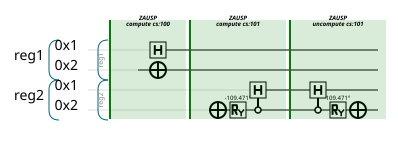

In [2]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.usp import ZAUSP

qpu = QPU(num_qubits=4)
reg1 = Qubits(2, "reg1", qpu)
reg2 = Qubits(2, "reg2", qpu)

usp = ZAUSP()
usp.compute(2, reg1)
usp.compute(3, reg2)
usp.uncompute()

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

If you need to uncompute multiple `compute` calls to the same Qubrick in any order other than the reverse of the order in which they were called, you can do that by creating multiple instances of this Qubrick. For example, if you call `qbk.compute` twice, `qbk.compute(1)` and `qbk.compute(2)`, and want to uncompute these calls in the same order, you can create two Qubrick instances, `qbk1` and `qbk2`, and call `compute` and `uncompute` on each one independently:

```python
qbk1 = Qubrick()
qbk2 = Qubrick()

qbk1.compute(1)
qbk2.compute(2)
qbk1.uncompute() # Will uncompute qbk1.compute(1)
qbk2.uncompute() # Will uncompute qbk2.compute(2)
```

## Simple dagger (adjoint)

You can only call `uncompute` method of a Qubrick after you've called its `compute` method; otherwise, Workbench doesn't have a record of instructions that need to be applied in reverse. However, sometimes an algorithm relies on calling the adjoint of a certain unitary before that unitary. A simple example is reflection about the mean used in Grover's search algorithm. It can be implemented as a sequence of three steps:

1. Adjoint of the unitary that prepares the "mean" - the uniform superposition of all basis states in the search space.
2. Reflection about the $|0\rangle$ state.
3. The unitary that prepares the "mean".

You can implement reflection about the mean using Qubricks that implement the "mean" state preparation and reflection about $|0\rangle$, but you'll need to call the inverse of the state preparation before you call the state preparation itself.

In this scenario, you don't need to implement the adjoint version of the Qubrick by hand, even though you can't call `uncompute` to run it. Instead, you can call the `compute` method with the extra argument `dagger=True`. This will generate the "daggered" (adjoint) version of the `compute` without having to apply `compute` first.

The following example shows how to implement reflection about the mean using the `USP` Qubrick which prepares a uniform superposition state. You can see that the first call to `state_prep` Qubrick within `ReflectAboutMean.compute` is `compute`, but it performs the _inverse_ of state preparation done by the `state_prep` due to the argument `dagger=True`. After that, the code calls `state_prep.uncompute` to undo this computation and run the "direct" state preparation logic.

|reg>
|0>    0.500000+0.000000j
|1>    0.500000+0.000000j
|2>    0.500000+0.000000j
|3>    0.500000+0.000000j
|reg>
|0>    0.500000-0.000000j
|1>    0.500000-0.000000j
|2>    0.500000-0.000000j
|3>    -0.500000-0.000000j


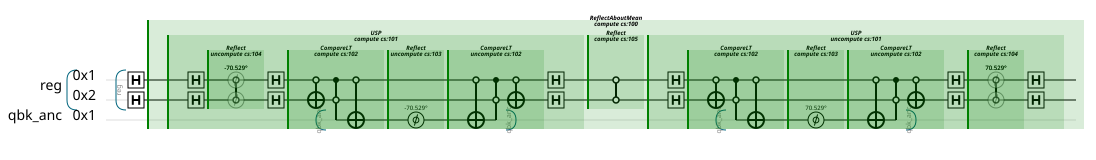

In [3]:
from psiqdk.workbench import QPU, Qubits, Qubrick
from psiqdk.workbench.usp import USP

class ReflectAboutMean(Qubrick):
    def __init__(self, state_prep: Qubrick, **kwargs):
        self.state_prep = state_prep
        super().__init__(**kwargs)

    def _compute(self, reg: Qubits, num_states: int) -> None:
        # Adjoint of state prep
        self.state_prep.compute(num_states, reg, dagger=True)

        # Reflection about |0⟩
        (~reg).reflect()

        # State prep
        self.state_prep.uncompute()


qpu = QPU(num_qubits=3)
reg = Qubits(2, "reg", qpu)

usp = USP()
reflect = ReflectAboutMean(usp)

reg.had()
reg.print_state_vector()

reflect.compute(reg, 3)   # Reflect about the state |0⟩ + |1⟩ + |2⟩
# Notice that the state vector is printed up to a global phase, 
# so it looks like reflection happened about the state |3⟩ instead
reg.print_state_vector()

qpu.draw(show_qubricks=True)

You can also pass the extra argument `dagger=True` to the Qubrick constructor. In this case, all calls to its `compute` method will apply the adjoint of the computation it implements.

## Custom uncomputation

Automatic uncomputation by reversing the order of instructions and replacing gates with their adjoints covers most uncomputation scenarios in quantum algorithms. However, sometimes it is possible to do uncomputation more efficiently than this. For example, you can compute an AND of two qubits using a _Gidney elbow_ - a Toffoli gate with the target qubit in the $|0\rangle$ state. You can uncompute this operation using another Toffoli gate, but it is more efficient to uncompute by measuring the target qubit in the $X$ basis and, depending on the measurement outcome, correcting the phase of the input qubits using a CZ gate.

If the Qubrick you're implementing has such an efficient uncomputation, you can specify its uncompute logic separately from its compute. To do this, you need to implement the `_uncompute` method of your Qubrick class. Similarly to `_compute`, this will generate an `uncompute` method (without an underscore) that will be called for uncomputation.

The following example shows how to implement a `ZeroTargetAND` Qubrick with different logic for `_compute` and `_uncompute` methods. Notice that the implementation of `_uncompute` doesn't take any arguments; they can be fetched from the Qubrick instance variables. In this case, `get_input_qreg` method allows the `_uncompute` method to access quantum registers that were passed as arguments to the corresponding `compute` call.

> Gidney elbows are broadly used in Workbench code, but they are treated as primitive methods and do not require further decomposition. The internal instruction management system (IMS) accepts elbows as primitive instructions and handles them under the hood. Here, we implement Gidney elbow as a Qubrick only as a simple illustration of doing custom uncomputation.

|input|target>
|0|0>    0.750000+0.000000j
|1|0>    0.433013+0.000000j
|2|0>    0.433013+0.000000j
|3|0>    0.250000+0.000000j
|input|target>
|0|0>    0.750000+0.000000j
|1|0>    0.433013+0.000000j
|2|0>    0.433013+0.000000j
|3|1>    0.250000+0.000000j
|input|target>
|0|0>    0.750000+0.000000j
|1|0>    0.433013+0.000000j
|2|0>    0.433013+0.000000j
|3|0>    0.250000+0.000000j


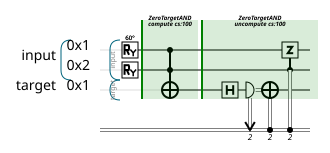

In [4]:
from psiqdk.workbench import QPU, Qubits, Qubrick

class ZeroTargetAND(Qubrick):
    """Qubrick to perform a zero-target AND gate."""
    def _compute(self, input: Qubits, target: Qubits) -> None:
        """Apply an AND gate, assuming that the target qubit is in the |0⟩ state.
        
        Args:
            input (Qubits): A two-qubit input register.
            target (Qubits): A single-qubit target register in the |0⟩.
        """
        assert input.num_qubits == 2 and target.num_qubits == 1
        target.x(cond=input)

    def _uncompute(self) -> None:
        """Measurement-based uncompute (more efficient)"""
        # Get input registers that were passed to _compute
        input = self.get_input_qreg("input")
        target = self.get_input_qreg("target")

        target.had()
        res = target.read_async()
        with res:
            # Reset the target qubit to |0⟩
            target.x()
            # Fixup the phase of the input qubits
            input[0].z(cond=input[1])
    

qpu = QPU(num_qubits=3)
input, target = Qubits(2, "input", qpu), Qubits(1, "target", qpu)

input.ry(60)
qpu.print_state_vector()

zand = ZeroTargetAND()
zand.compute(input, target)
qpu.print_state_vector()

zand.uncompute()
qpu.print_state_vector()

qpu.draw(show_qubricks=True)

The next example shows custom uncompute for a more complicated scenario: a table lookup. `DataLookupClean` Qubrick loads the data into qubit registers using a sequence of SELECT and SWAP routines, which, in turn, are implemented as sequences of controlled gates. However, simple reversal of these gate sequences is not the most efficient way to do uncomputation. Measurement-based uncomputation relies on measuring the "output" register and applying phase fixup gates to the "index" register. (Same as in the previous example, this is possible because the "output" register is guaranteed to start in the $|0\rangle$ state.)

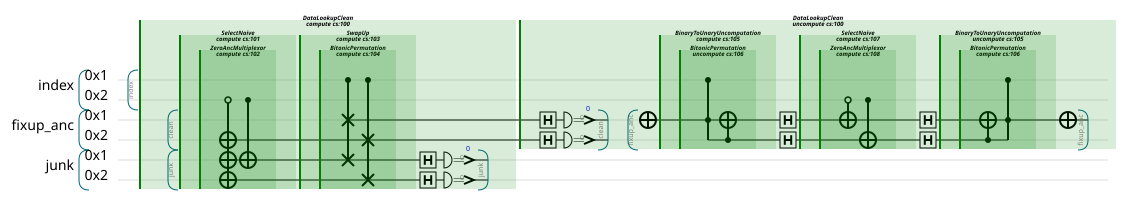

In [5]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms import DataLookupClean, SelectNaive, SwapUp

lambda_val = 2
index_size = 2
precision = 2
data = [2, 3, 0, 1]

qpu = QPU(num_qubits=index_size + precision * lambda_val)
index = Qubits(index_size, "index", qpu)

select = SelectNaive()
swap_up = SwapUp()
qrom = DataLookupClean(select=select, swap_up=swap_up)

qrom.compute(index_reg=index, bits_of_precision=precision, data=data, lambda_val=lambda_val)
qrom.uncompute()

qpu.draw(show_qubricks=True)

## Disabling uncomputation

For Qubricks which implement a unitary transformation uncomputation is a well-defined operation. However, sometimes a Qubrick implements a non-reversible transformation, such as a measurement. In these cases, defining an uncompute method doesn't make sense. Furthermore, if the code tries to call `uncompute` for an instance of such a Qubrick, it's very likely an error in the code.

If you're developing a Qubrick and want to make sure that its `uncompute` method is never called, you can prohibit calling it by passing a flag `never_uncompute=True` to the constructor of its superclass. This way, trying to call the `uncompute` method of your Qubrick will raise an error. 

The following example shows how to modify the definition of the `ParityMeasurement` Qubrick from an earlier tutorial to disable calling its `uncompute` method. The class definition has an explicit constructor which calls the superclass constructor with an extra parameter.

> You can also pass the `never_uncompute=True` as an argument when creating a Qubrick. However, in this case the decision is made by the application developer who uses the Qubrick, not the designer of that Qubrick.

In [6]:
from psiqdk.workbench import QPU, Qubits, Qubrick

class ParityMeasurement(Qubrick):
    """Qubrick to perform a parity measurement."""
    def __init__(self, name=None, **kwargs):
        super().__init__(name, never_uncompute=True, **kwargs)

    def _compute(self, reg: Qubits) -> None:
        res = reg.ppm(1, 0, ~0)
        self.set_classical_result(res, "parity")
    

qpu = QPU(num_qubits=4)
reg = Qubits(4, "reg", qpu)

pm = ParityMeasurement()
pm.compute(reg)

try:
    pm.uncompute()
except Exception as e:
    print(e)

Qubrick [ParityMeasurement] is marked as never_uncompute but uncompute() was called.


It can also be useful to disable uncomputation for a Qubrick you're using in your code if you know you're not planning to call its `uncompute` method - either because your code won't need it at all or because you're focusing on getting the computation itself right and will add the uncomputation steps later. Storing gates for their potential use during uncomputation might require considerable memory, especially for large and complicated Qubricks, and turning off uncomputation upfront will save that memory.

In this case, you can pass the `never_uncompute=True` as one of the arguments when creating a Qubrick:

```python
qft = QFT(never_uncompute=True)
```

## Next steps

In this tutorial, you've learned to use Workbench Qubricks for uncomputation. The next tutorial will discuss another common use of Qubricks - [defining their controlled variants](./Qubricks-Controlled.ipynb). A later tutorial shows a more concise way to use uncomputation via a [context manager](./Qubricks-Computed-Context-Manager.ipynb).